# Machine Learning for CICY 4-Folds

H. Erbin, R. Finotello

Following the analysis in [arXiv:2007.13379](https://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](https://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds.
The idea is to see whether the Inception network can also be applied in higher dimensions.

## Exploratory Data Analysis

Using the [feature engineered dataset](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.txt), we tidy the dataset for the exploratory data analysis.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from nn_tools.utils.plotutils import *

In [2]:
sns.set_theme()
sns.set_context('paper')
ratio   = lambda x, y: (6 * y, 5 * x)

os.makedirs('./img', exist_ok=True)
os.makedirs('./models', exist_ok=True)

## Download the Dataset

We download the dataset containing the engineered features of CICY 4-folds.
Since the dataset is large we start by considering only the scalar **engineered features** (see the [documentation](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.txt) for the name of the columns).

In [3]:
df = pd.read_json('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz', orient='index')

In [4]:
df = df.drop(columns=df.loc[:,df.dtypes == 'object'].columns)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 921497 entries, 1 to 921497
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   euler           921497 non-null  int64  
 1   favour          921497 non-null  bool   
 2   h11             905684 non-null  float64
 3   h21             905684 non-null  float64
 4   h22             905684 non-null  float64
 5   h31             905684 non-null  float64
 6   isprod          921497 non-null  bool   
 7   num_cp          921497 non-null  int64  
 8   num_eqs         921497 non-null  int64  
 9   num_cp_1        921497 non-null  int64  
 10  num_cp_2        921497 non-null  int64  
 11  num_cp_neq1     921497 non-null  int64  
 12  num_ex          921497 non-null  int64  
 13  norm_matrix     921497 non-null  float64
 14  rank_matrix     921497 non-null  int64  
 15  min_dim_cp      921497 non-null  int64  
 16  max_dim_cp      921497 non-null  int64  
 17  mean_dim_c

## Complete Cases

In the dataset there are incomplete cases for $h^{1,1}$, $h^{2,1}$, $h^{3,1}$ and $h^{2,2}$.

In [6]:
df.isna().sum()

euler                 0
favour                0
h11               15813
h21               15813
h22               15813
h31               15813
isprod                0
num_cp                0
num_eqs               0
num_cp_1              0
num_cp_2              0
num_cp_neq1           0
num_ex                0
norm_matrix           0
rank_matrix           0
min_dim_cp            0
max_dim_cp            0
mean_dim_cp           0
std_dim_cp            0
median_dim_cp         0
min_deg_eqs           0
max_deg_eqs           0
mean_deg_eqs          0
std_deg_eqs           0
median_deg_eqs        0
dtype: int64

For the exploratory data analysis we investigate on their nature:

In [7]:
df.loc[df['isprod'] == True, 'h11':'h31'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15813 entries, 41 to 919969
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   h11     0 non-null      float64
 1   h21     0 non-null      float64
 2   h22     0 non-null      float64
 3   h31     0 non-null      float64
dtypes: float64(4)
memory usage: 617.7 KB


In [8]:
df.loc[df['isprod'] == False, 'h11':'h31'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 905684 entries, 1 to 921497
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   h11     905684 non-null  float64
 1   h21     905684 non-null  float64
 2   h22     905684 non-null  float64
 3   h31     905684 non-null  float64
dtypes: float64(4)
memory usage: 34.5 MB


As we can see the incomplete cases are fully linked to the configuration matrix being a product space.
We can therefore discard the corresponding rows from the dataset:

In [9]:
df = df.loc[df['isprod'] == False].drop(columns=['isprod'])

## Data Types Conversion

We then convert the data types of the Hodge numbers for optimisation.

In [10]:
labels = ['h11', 'h21', 'h31', 'h22']

In [11]:
for label in labels:
    df[label] = df[label].astype(np.int)

In [12]:
def py_to_tex(label):
    '''
    Print in TeX form the label.
    
    Required argument:
        label: the string containing the Hodge number label to print in TeX format.
    '''
    
    return f'$h^{{ {label[1]}, {label[2]} }}$'

## Distribution of the Labels

As a first analysis we provide the univariate distributions of the labels:

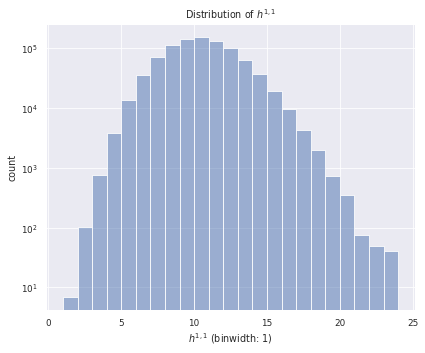

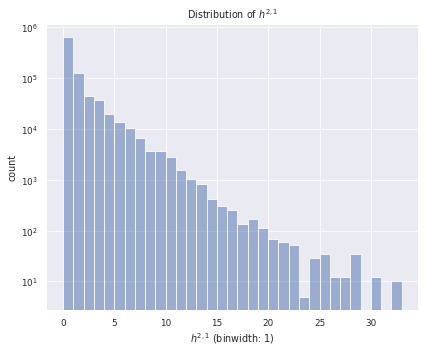

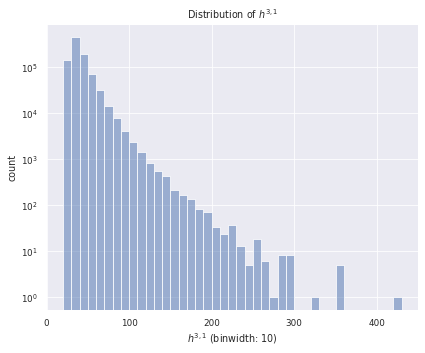

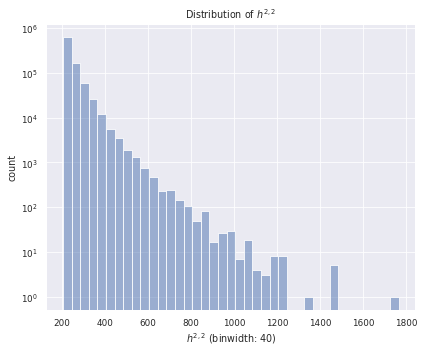

In [13]:
binwidths = {'h11': 1,
             'h21': 1,
             'h31': 10,
             'h22': 40
            }

for label, binwidth in binwidths.items():
    plot_univariate(df[label],
                    out_name='distr_' + label,
                    root='./img',
                    binwidth=binwidth,
                    title=f'Distribution of {py_to_tex(label)}',
                    xlabel=f'{py_to_tex(label)} (binwidth: {binwidth})',
                    ylabel='count',
                    yscale='log',
                    show=True,
                    save_pdf=True,
                   )

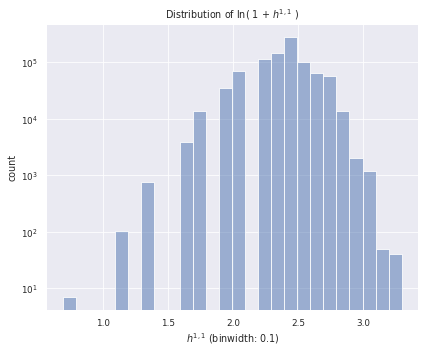

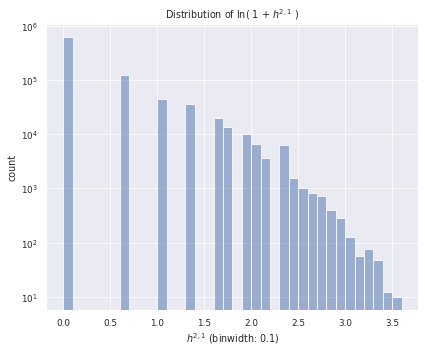

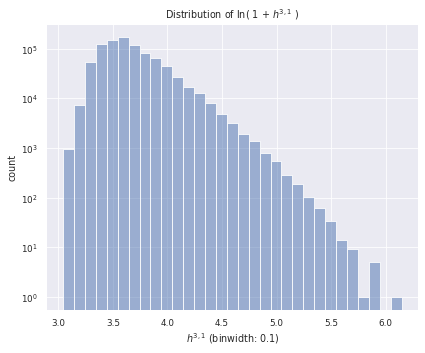

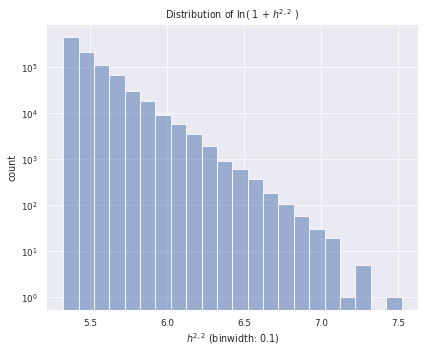

In [14]:
binwidths = {'h11': 0.1,
             'h21': 0.1,
             'h31': 0.1,
             'h22': 0.1
            }

for label, binwidth in binwidths.items():
    plot_univariate(df[label].apply(np.log1p),
                    out_name='distr_' + label,
                    root='./img',
                    binwidth=binwidth,
                    title=f'Distribution of ln( 1 + {py_to_tex(label)} )',
                    xlabel=f'{py_to_tex(label)} (binwidth: {binwidth})',
                    ylabel='count',
                    yscale='log',
                    show=True,
                    save_pdf=True,
                   )

## Distributions of the Values

We then look at the distribution of the values of the labels in more detail.
Specifically, we show the top 5 Hodge numbers in frequency.

In [15]:
for label in labels:
    group = df[[label, 'num_cp']].groupby(by=[label])\
                                 .count()\
                                 .sort_values(by=['num_cp'], ascending=False)\
                                 .apply(lambda x: x / x.sum())\
                                 .head(5)
    
    print(group)

       num_cp
h11          
10   0.167218
9    0.159483
11   0.146515
8    0.125502
12   0.110053
       num_cp
h21          
0    0.700535
1    0.136593
2    0.049948
3    0.040652
4    0.021989
       num_cp
h31          
32   0.059509
34   0.054964
30   0.054447
31   0.053767
33   0.052687
       num_cp
h22          
204  0.106830
216  0.085727
228  0.070361
208  0.049807
212  0.047837


As we can see $h^{2,1}$ vanishes ~70% of the times.
This will indeed be a difficult number to predict well.

## Correlations and Covariance

Given the distributions we then study the correlations between the variables.

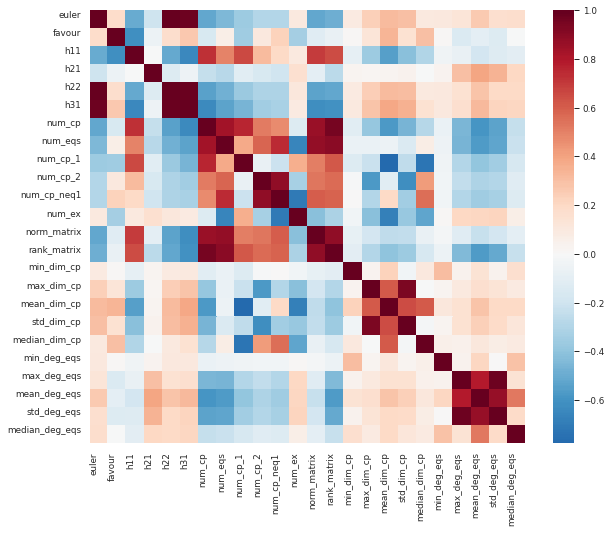

In [16]:
plot_corr(df,
          out_name='corr_eng_feat',
          root='./img',
          base_ratio=(1.5,1.5),
          show=True,
          save_pdf=True
         )

As usual the engineered features look correlated.
In particular correlation of features of the same "type" is more pronounced.

## Distribution of the Features

We then study the distribution of features with respect to the labels.
For future use in this exploratory analysis, we change the name of the variable `favour` into embedding and assign the values `True = favourable` and `False = non favourable`.

In [17]:
df = df.rename(columns={'favour': 'embedding'})
df.loc[:, 'embedding'] = df['embedding'].astype('category').cat.rename_categories(['non favourable', 'favourable'])

We can then visualise the resulting distributions in scatter plots.

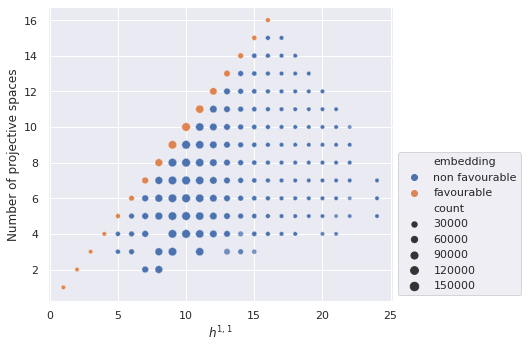

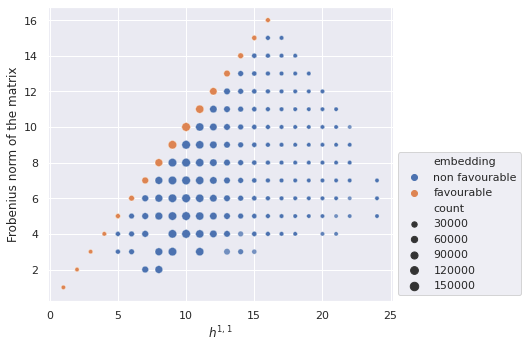

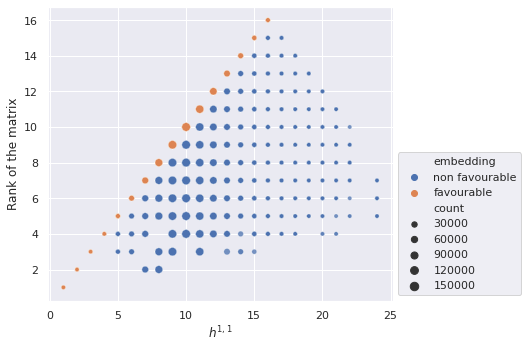

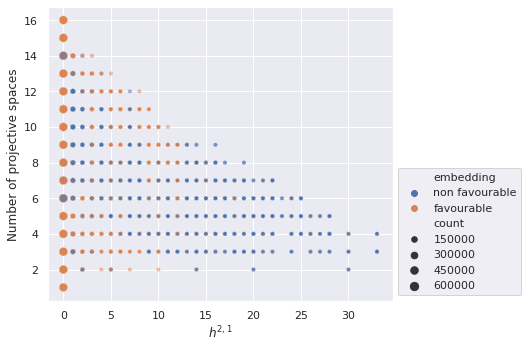

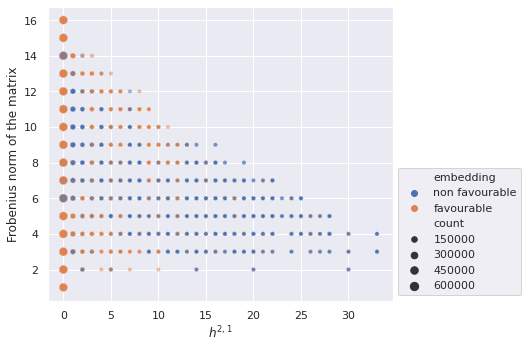

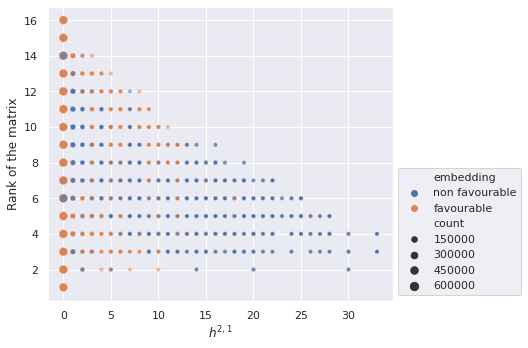

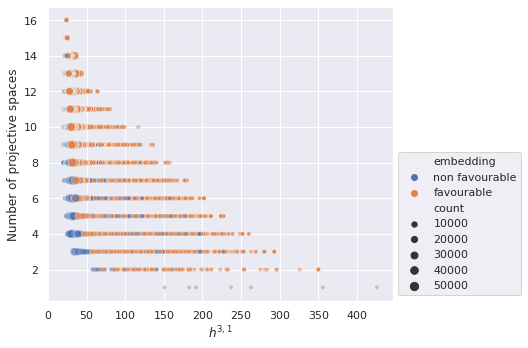

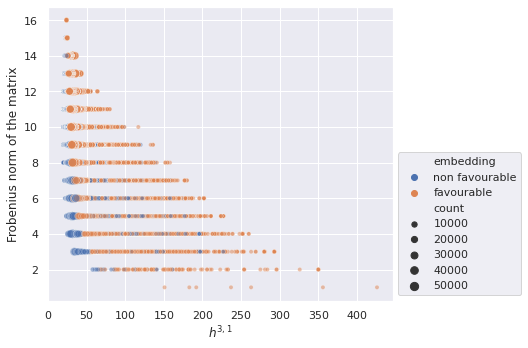

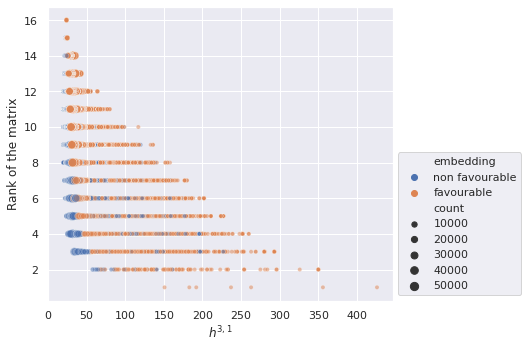

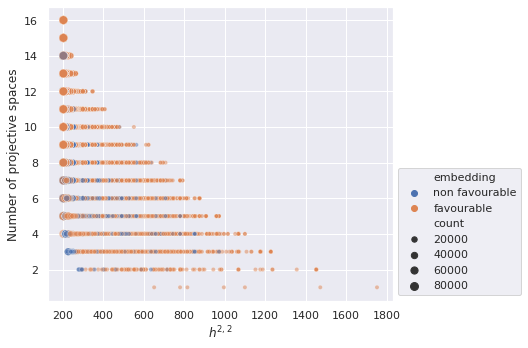

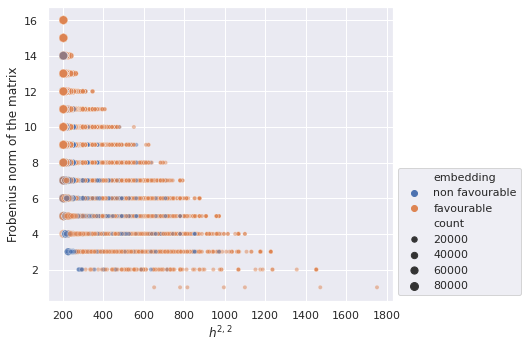

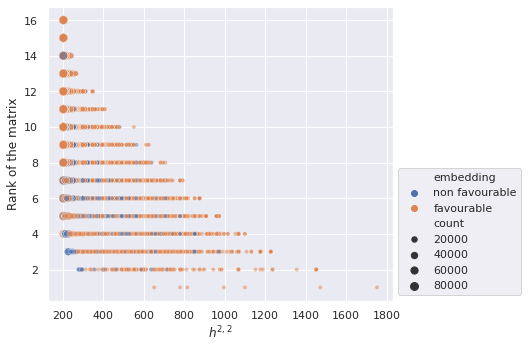

In [21]:
variable_labels = {'num_cp':      'Number of projective spaces',
                   'norm_matrix': 'Frobenius norm of the matrix',
                   'rank_matrix': 'Rank of the matrix'
                  }

for label in labels:
    
    for variable, ylabel in variable_labels.items():
        
        # count the unique values
        df['count'] = np.zeros((df.shape[0],), dtype=np.int)
        for n in df[label].unique():
            df.loc[df[label] == n, 'count'] = int(df.loc[df[label] == n, variable].count())

        # plot the bivariate distribution
        plot_bivariate(data=df,
                       x=label,
                       y='num_cp',
                       hue='embedding',
                       size='count',
                       out_name=variable + '_vs_' + label,
                       root='./img',
                       xlabel=py_to_tex(label),
                       ylabel=ylabel,
                       base_ratio=(1.25,1),
                       show=True,
                       save_pdf=True
                      )